

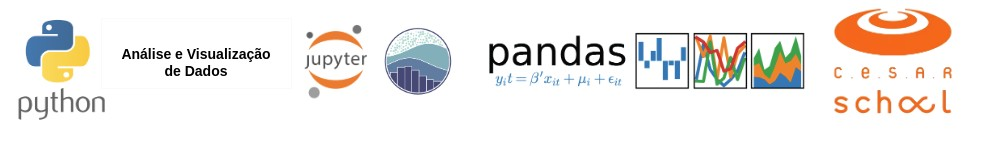



# **Logística/Comercial (compras, vendas e produtos)**

**Professor:** Matheus Soares msl3@cesar.school

**Grupo 05**

**Alunos:**

SEVERINO HENRIQUE DE ARAUJO NETO

MATEUS ALBUQUERQUE FALCAO

LAURA SILVA SOARES DE MELO

THIAGO ROBERTO CAVALCANTI
            
RAFAEL FERREIRA SALGADO

### **Contexto**

Uma empresa internacional de comércio eletrônico, com sede em [local omitido], deseja descobrir informações importantes a partir de seu banco de dados de clientes. Para isso, pretende utilizar algumas das técnicas de aprendizado de máquina mais avançadas disponíveis. A empresa vende produtos eletrônicos.



### **Problemática**

1. Perfis de clientes por comportamento de compra
    - Quais grupos de clientes se formam com base em suas características de compra?

2. Padrões de risco de atraso na entrega
    - Existem grupos de pedidos com perfil similar e alto risco de não chegar no prazo?

3. Classificação de produtos por custo e importância
    - Quais grupos de produtos emergem por características de valor e cuidado logístico?

4. Perfis de insatisfação e retenção
    -  grupos combinam baixa avaliação, muitos contatos e alto desconto aplicado?

5. Grupos de operação logística por modal e armazém
    -  combinações de armazém e modal criam padrões distintos de custo e desempenho?


### Bibliotecas

In [1]:
# 📥 Importação das Bibliotecas
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots



# Configuração para exibir melhor os dados
pd.set_option('display.float_format', '{:.2f}'.format)

### Exploração dos Dados

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Carregar dataset
path = "/content/Train.csv"
df = pd.read_csv(path, encoding='latin-1')
df.head(10)


,ï»¿ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [4]:
# Informações das varáveis do datset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ï»¿ID                10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [5]:
df.describe()

,ï»¿ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00
mean,5500.00,4.05,2.99,210.20,3.57,13.37,3634.02,0.60
std,3175.28,1.14,1.41,48.06,1.52,16.21,1635.38,0.49
min,1.00,2.00,1.00,96.00,2.00,1.00,1001.00,0.00
25%,2750.50,3.00,2.00,169.00,3.00,4.00,1839.50,0.00
50%,5500.00,4.00,3.00,214.00,3.00,7.00,4149.00,1.00
75%,8249.50,5.00,4.00,251.00,4.00,10.00,5050.00,1.00
max,10999.00,7.00,5.00,310.00,10.00,65.00,7846.00,1.00


----------------------------------------------------------------------------------------------------------------------------------------------------------------

### Análise Exploratória Simples


In [6]:
# valores calculados
desc = df.groupby("Reached.on.Time_Y.N")["Discount_offered"].mean()
peso = df.groupby("Reached.on.Time_Y.N")["Weight_in_gms"].mean()
sac  = df.groupby("Reached.on.Time_Y.N")["Customer_care_calls"].mean()

ordem      = ["low", "medium", "high"]
labels     = ["Low", "Medium", "High"]
valores_imp = [df[df["Product_importance"] == imp]["Reached.on.Time_Y.N"].mean() for imp in ordem]

COR_PRAZO    = "#1D9E75"
COR_ATRASADO = "#D85A30"
COR_ROXO     = "#534AB7"
COR_CINZA    = "#888780"

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "Desconto médio oferecido",
        "Peso médio (gramas)",
        "Ligações ao SAC (média)",
        "Taxa no prazo por importância"
    ],
    vertical_spacing=0.22,
    horizontal_spacing=0.12
)

fig.add_trace(go.Bar(
    x=["No prazo", "Atrasado"], y=[desc[1], desc[0]],
    marker_color=[COR_PRAZO, COR_ATRASADO],
    text=[f"{desc[1]:.1f}%", f"{desc[0]:.1f}%"],
    textposition="outside", textfont=dict(size=13),
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Bar(
    x=["No prazo", "Atrasado"], y=[peso[1], peso[0]],
    marker_color=[COR_PRAZO, COR_ATRASADO],
    text=[f"{peso[1]:,.0f}g", f"{peso[0]:,.0f}g"],
    textposition="outside", textfont=dict(size=13),
    showlegend=False
), row=1, col=2)

fig.add_trace(go.Bar(
    x=["No prazo", "Atrasado"], y=[sac[1], sac[0]],
    marker_color=[COR_PRAZO, COR_ATRASADO],
    text=[f"{sac[1]:.1f}", f"{sac[0]:.1f}"],
    textposition="outside", textfont=dict(size=13),
    showlegend=False
), row=2, col=1)

fig.add_trace(go.Bar(
    x=labels, y=valores_imp,
    marker_color=[COR_ROXO, COR_CINZA, COR_CINZA],
    text=[f"{v:.0%}" for v in valores_imp],
    textposition="outside", textfont=dict(size=13),
    showlegend=False
), row=2, col=2)

fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="#1a1a1a",
    plot_bgcolor="#2a2a2a",
    title=dict(text="Análise Exploratória - Logística", font=dict(size=18)),
    height=650,
    margin=dict(t=80, b=40, l=40, r=40)
)

fig.update_traces(marker_line_width=0)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor="#444")

fig.show()

-----------------------------------------------------------------

### Tratamento dos Dados

In [7]:
# RENOMEAR COLUNAS PROBLEMÁTICAS
df = df.rename(columns={df.columns[0]: "ID"})
# REMOVER ID
df = df.drop(columns=["ID"])

In [8]:
# Encoding
# Tem como Objetivo transformar texto em número

df["Gender"]           = df["Gender"].map({"F": 0, "M": 1})
df["Warehouse_block"]  = df["Warehouse_block"].map({"A": 0, "B": 1, "C": 2, "D": 3, "F": 4})
df["Mode_of_Shipment"] = df["Mode_of_Shipment"].map({"Flight": 0, "Road": 1, "Ship": 2})
df["Product_importance"] = df["Product_importance"].map({"low": 0, "medium": 1, "high": 2})


In [9]:
# Separar a variável alvo antes de normalizar
target   = df["Reached.on.Time_Y.N"]
features = df.drop(columns=["Reached.on.Time_Y.N"])

In [10]:
# Normalização
# coloca todas as colunas na mesma escala
scaler    = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

print(df_scaled.head())

   Warehouse_block  Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0             0.45             -2.00                -0.05            -0.70   
1             1.12             -2.00                -0.05             1.42   
2            -1.57             -2.00                -1.80            -0.70   
3            -0.89             -2.00                -0.92             0.01   
4            -0.22             -2.00                -1.80            -0.70   

   Cost_of_the_Product  Prior_purchases  Product_importance  Gender  \
0                -0.69            -0.37               -0.94   -0.99   
1                 0.12            -1.03               -0.94    1.01   
2                -0.57             0.28               -0.94    1.01   
3                -0.71             0.28                0.62    1.01   
4                -0.55            -0.37                0.62   -0.99   

   Discount_offered  Weight_in_gms  
0              1.89          -1.47  
1              2.82          -

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### PROBLEMÁTICA 4: Insatisfação e retenção — Hierárquico

Motivo por usar Hierárquico: Com poucas variáveis, o clustering hierárquico gera um dendrograma — um gráfico de árvore que mostra como os grupos se formam. Isso ajuda a visualizar se os clientes insatisfeitos formam um grupo único ou se existem subgrupos dentro deles, antes de decidir quantos clusters usar.

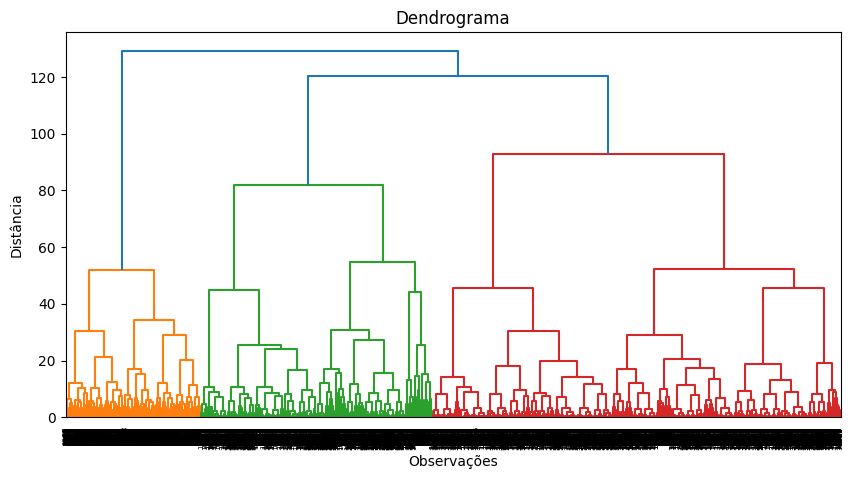

In [15]:
cols_4 = ["Customer_rating", "Customer_care_calls", "Prior_purchases", "Discount_offered"]
X4 = df_scaled[cols_4]
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X4, method='ward')


plt.figure(figsize=(10, 5))
dendrogram(Z, color_threshold=120)
plt.title("Dendrograma")
plt.xlabel("Observações")
plt.ylabel("Distância")
plt.show()

In [16]:
from scipy.cluster.hierarchy import fcluster
for t in [20, 40, 55, 60, 80]:
    clusters = fcluster(Z, t=t, criterion='distance')
    print(f"\nCorte em {t}")
    print("Nº clusters:", len(set(clusters)))


Corte em 20
Nº clusters: 25

Corte em 40
Nº clusters: 12

Corte em 55
Nº clusters: 5

Corte em 60
Nº clusters: 5

Corte em 80
Nº clusters: 5


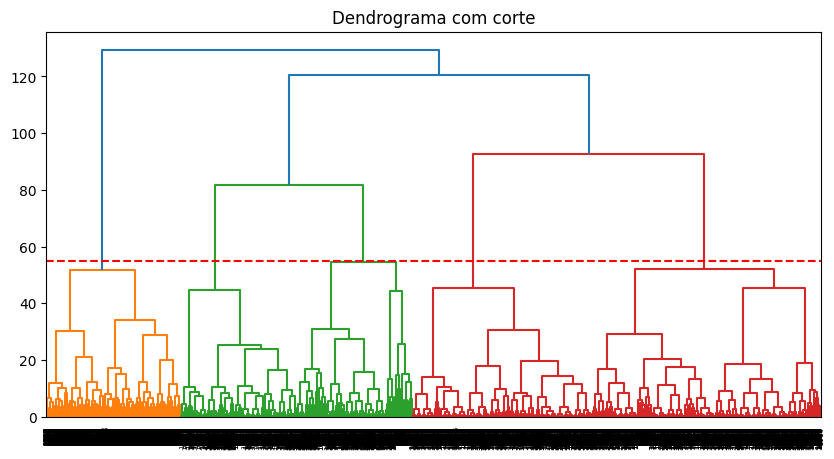

In [17]:
plt.figure(figsize=(10,5))
dendrogram(Z, color_threshold=120)
plt.axhline(y=55, color='r', linestyle='--')  # corte em 55
plt.title("Dendrograma com corte")
plt.show()

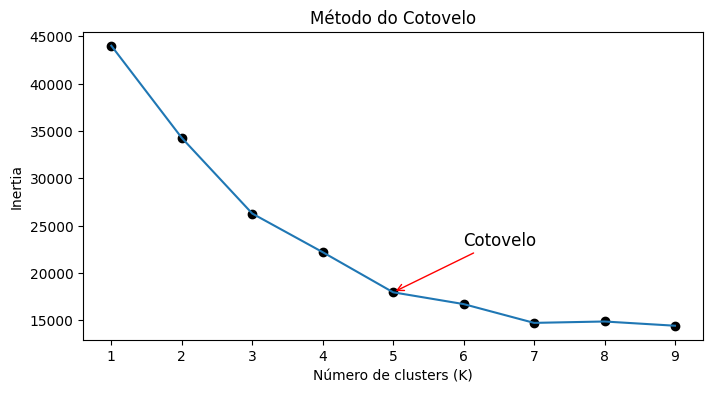

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X4)
    inertia.append(kmeans.inertia_)

# Ponto do cotovelo (K = 5)
k_point = 5
y_point = inertia[k_point - 1]

# Plot
plt.figure(figsize=(8, 4))

# Linha azul
plt.plot(K_range, inertia)

# Pontos pretos (agora forçado)
plt.scatter(K_range, inertia, color='black')

# Seta apontando para o cotovelo
plt.annotate(
    'Cotovelo',
    xy=(k_point, y_point),
    xytext=(k_point + 1, y_point + 5000),
    arrowprops=dict(arrowstyle='->', color='red'),  # seta vermelha
    fontsize=12
)

plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [19]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=5)
df["cluster"] = hier.fit_predict(X4)

In [20]:
df.groupby("cluster")[cols_4].mean().round(2)

,Customer_rating,Customer_care_calls,Prior_purchases,Discount_offered
cluster,,,,
0,2.15,4.12,5.84,11.45
1,2.89,3.72,2.85,42.77
2,4.16,3.42,3.13,6.89
3,1.83,3.93,2.69,5.75
4,3.45,5.82,4.38,5.67


# Classificação Cluster:

## Cluster 0 — Insatisfeito frequente
baixo rating (2.15),
muitas chamadas,
compras razoáveis (5.84),
desconto médio.
Perfil: Compra, mas tem problemas.
Ação: melhorar experiência e reduzir atritos (logística, suporte)
-------------------------------------
## Cluster 1 — Caçador de desconto
rating médio,
chamadas médias,
poucas compras,
DESCONTO MUITO ALTO (42.77).
Perfil: Só compra com promoção.
Ação: evitar dar desconto excessivo e trabalhar valor da marca e campanhas inteligentes
-------------------------------------
## Cluster 2 — Cliente satisfeito (melhor grupo)
maior rating (4.16),
menos chamadas,
compras moderadas,
pouco desconto.
Perfil: Cliente saudável.
Ação: fidelizar
---------------------------------------
## Cluster 3 — Crítico (pior grupo)
rating mais baixo (1.83),
muitas chamadas,
poucas compras,
pouco desconto,
Perfil: Cliente insatisfeito e engajamento baixo.
Risco: altíssimo churn.
Ação: investigar problemas no atendimento e campanhas de recuperação
----------------------------------------
## Cluster 4 — Engajado com problemas
rating ok (3.45),
muitas chamadas (5.82),
boas compras,
pouco desconto,
Perfil: Cliente ativo, mas com dor.
Ação:melhorar suporte e pode virar VIP se resolver problemas

In [38]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2, 6):  # começa em 2 e vai até 5
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X4)
    score = silhouette_score(X4, labels)
    print(f"k={k} → Silhouette: {round(score, 3)}")

k=2 → Silhouette: 0.274
k=3 → Silhouette: 0.246
k=4 → Silhouette: 0.205
k=5 → Silhouette: 0.234
